In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

Matplotlib is building the font cache; this may take a moment.
/Users/kuroyami/neural_network_learning/env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
frame = load_diabetes(as_frame = True).frame

In [3]:
frame.shape

(442, 11)

In [4]:
frame.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
X, y = load_diabetes(return_X_y = True)

In [6]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

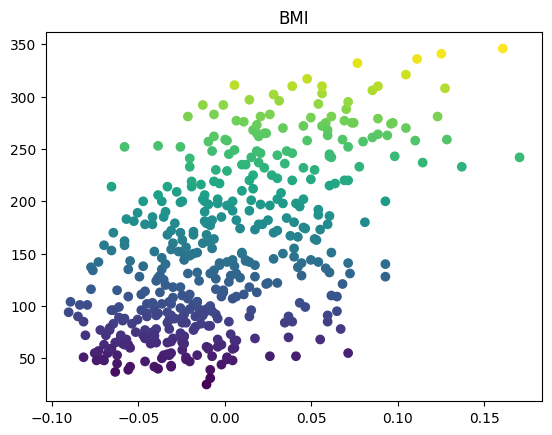

In [7]:
plt.scatter(frame["bmi"], frame["target"], c=y)
plt.title("BMI")
# plt.legend()
plt.show()

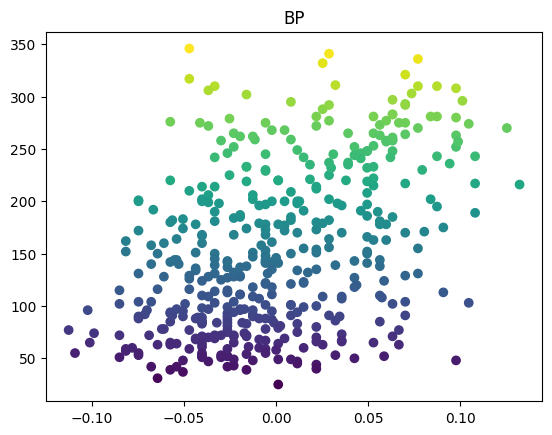

In [8]:
plt.scatter(frame["bp"], frame["target"], c=y)
plt.title("BP")
plt.show()

In [9]:
y[:5]

array([151.,  75., 141., 206., 135.])

<Axes: >

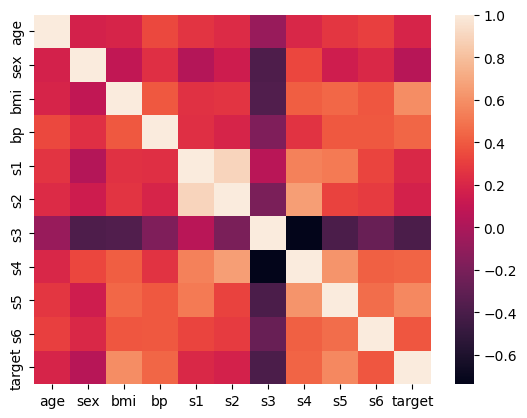

In [10]:
sns.heatmap(frame.corr())

In [11]:
X_tensor = torch.tensor(X, dtype = torch.float32)
y_tensor = torch.tensor(y, dtype = torch.float32)

In [12]:
X_tensor[:2], y_tensor[:2]

(tensor([[ 0.0381,  0.0507,  0.0617,  0.0219, -0.0442, -0.0348, -0.0434, -0.0026,
           0.0199, -0.0176],
         [-0.0019, -0.0446, -0.0515, -0.0263, -0.0084, -0.0192,  0.0744, -0.0395,
          -0.0683, -0.0922]]),
 tensor([151.,  75.]))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size = 0.2, shuffle = True, random_state = 42)

In [14]:
len(X_train), len(X_test), len(y_train), len(y_test)

(353, 89, 353, 89)

In [15]:
X_train.dim(), y_train.unsqueeze(dim=1).dim()

(2, 2)

In [16]:
class DiabetesModel(torch.nn.Module):
    def __init__(self, in_features: int = 10, out_features: int = 10, hidden_units: int = 10):
        super(DiabetesModel, self).__init__()
    
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
    
        self.network: torch.nn.Sequential = torch.nn.Sequential(
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [17]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [18]:
model = DiabetesModel(in_features = X_train.shape[1], out_features = 1).to(device)
model

DiabetesModel(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [19]:
model.eval()

with torch.inference_mode():
    y_pred = model(X_test.to(device))
    
y_pred[:5], y_train[:5]

(tensor([[0.0317],
         [0.0316],
         [0.0293],
         [0.0255],
         [0.0342]], device='mps:0'),
 tensor([144., 150., 280., 125.,  59.]))

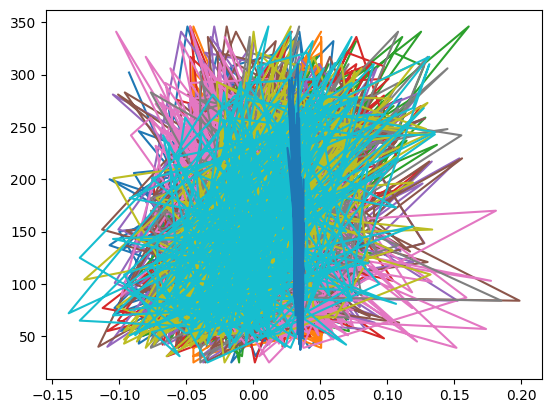

In [20]:
plt.plot(X_train.detach().cpu(), y_train.detach().cpu())
plt.plot(y_pred.squeeze().detach().cpu(), y_test.detach().cpu())

In [21]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2, weight_decay = 1e-4)

In [22]:
epochs = 1000

total_epochs, losses, test_losses = [], [], []
train_r2_scores, test_r2_scores = [], []

for epoch in tqdm(range(epochs)):
    model.train()

    y_pred = model(X_train.to(device)).squeeze()
    loss = criterion(y_pred, y_train.to(device))
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    train_r2 = r2_score(y_train, y_pred.detach().cpu())
    train_r2_scores.append(train_r2)

    model.eval()
    with torch.inference_mode():
        y_test_pred = model(X_test.to(device)).squeeze()
        test_loss = criterion(y_test_pred, y_test.to(device))

        test_r2 = r2_score(y_test, y_test_pred.detach().cpu())
        test_losses.append(test_loss.item())
        test_r2_scores.append(test_r2)

    total_epochs.append(epoch)

    if epoch % (epochs // 10) == 0:
        print(f"Training loss: {loss}, Testing loss: {test_loss}")
        print(f"Training R2: {train_r2} | Testing R2: {test_r2}")

  3%|█▎                                       | 31/1000 [00:00<00:22, 42.70it/s]

Training loss: 29701.4921875, Testing loss: 26530.27734375
Training R2: -3.888010135016345 | Testing R2: -4.007458860102136


 14%|█████▍                                 | 141/1000 [00:01<00:04, 194.74it/s]

Training loss: 6804.98095703125, Testing loss: 5406.345703125
Training R2: -0.11990378962240178 | Testing R2: -0.02042111482974529


 25%|█████████▊                             | 252/1000 [00:01<00:02, 295.31it/s]

...

 85%|████████████████████████████████▉      | 846/1000 [00:03<00:00, 367.23it/s]

Training loss: 2897.52587890625, Testing loss: 2897.17724609375
Training R2: 0.5231507619350908 | Testing R2: 0.45317213541822277


 96%|█████████████████████████████████████▎ | 958/1000 [00:03<00:00, 368.33it/s]

Training loss: 2894.81689453125, Testing loss: 2898.730224609375
Training R2: 0.5235965756917986 | Testing R2: 0.45287898564448326


100%|██████████████████████████████████████| 1000/1000 [00:03<00:00, 275.03it/s]


In [23]:
model.eval()

with torch.inference_mode():
    y_pred = model(X_test.to(device)).squeeze()
    y_pred = torch.round(y_pred)

y_pred[:5], y_train[:5]

(tensor([140., 182., 138., 296., 121.], device='mps:0'),
 tensor([144., 150., 280., 125.,  59.]))

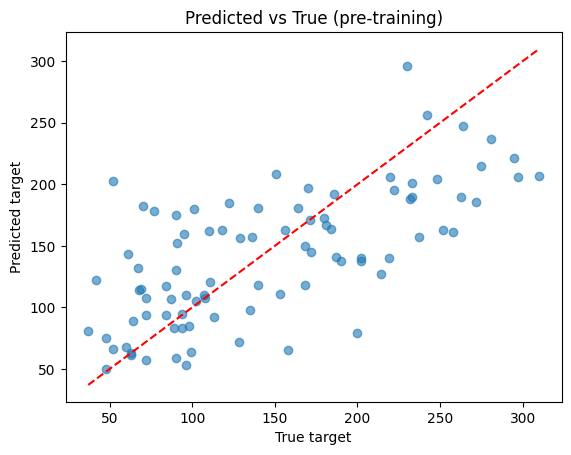

In [28]:
import numpy as np
y_test_cpu = y_test.detach().cpu().numpy() if 'y_test' in globals() else None
y_pred_cpu = y_pred.detach().cpu().numpy() if 'y_pred' in globals() else None
if y_test_np is not None and y_pred_np is not None:
    plt.scatter(y_test_np, y_pred_np, alpha=0.6)
    mn = min(y_test_np.min(), y_pred_np.min())
    mx = max(y_test_np.max(), y_pred_np.max())
    plt.plot([mn, mx], [mn, mx], 'r--')
    plt.xlabel('True target')
    plt.ylabel('Predicted target')
    plt.title('Predicted vs True (pre-training)')
    plt.show()
else:
    print('y_test or y_pred not available yet; run evaluation cell first')

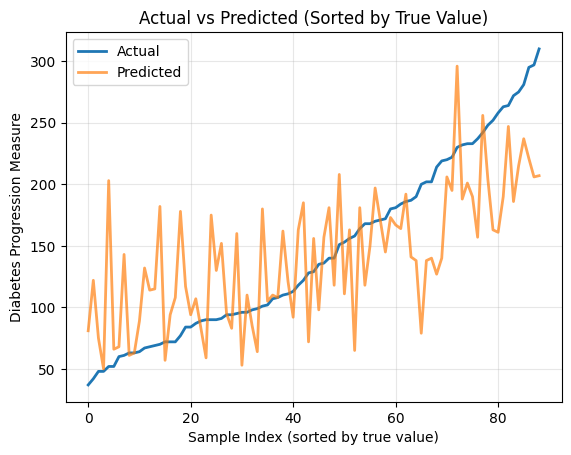

In [29]:
sorted_idx = y_test_cpu.argsort()
plt.plot(y_test_cpu[sorted_idx], label='Actual', linewidth=2)
plt.plot(y_pred_cpu[sorted_idx], label='Predicted', linewidth=2, alpha=0.7)
plt.title("Actual vs Predicted (Sorted by True Value)")
plt.xlabel("Sample Index (sorted by true value)")
plt.ylabel("Diabetes Progression Measure")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


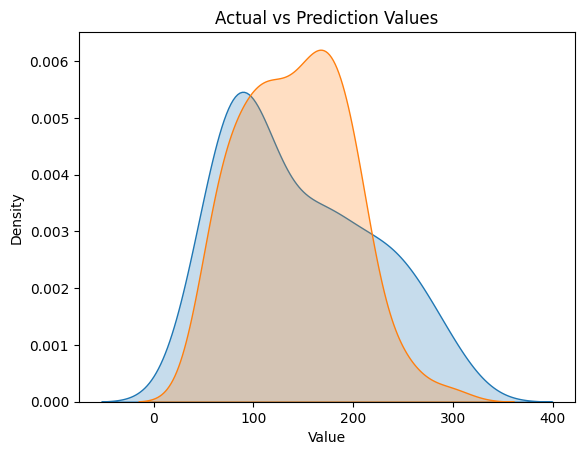

In [30]:
sns.kdeplot(y_test_cpu, label="Actual", fill= True)
sns.kdeplot(y_pred_cpu, label="Prediction", fill = True)
plt.title("Actual vs Prediction Values")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

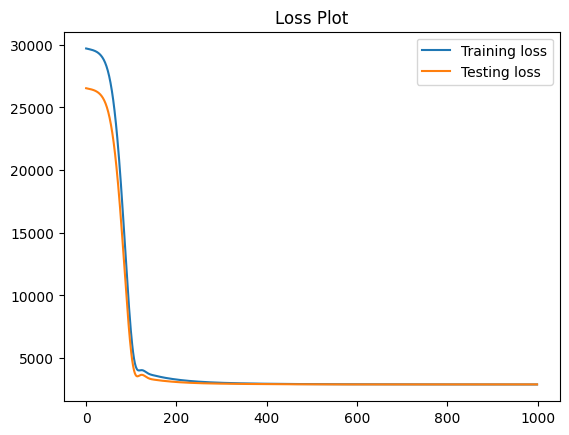

In [31]:
plt.plot(total_epochs, losses, label="Training loss")
plt.plot(total_epochs, test_losses, label="Testing loss")
plt.title("Loss Plot")
plt.legend()
plt.show()

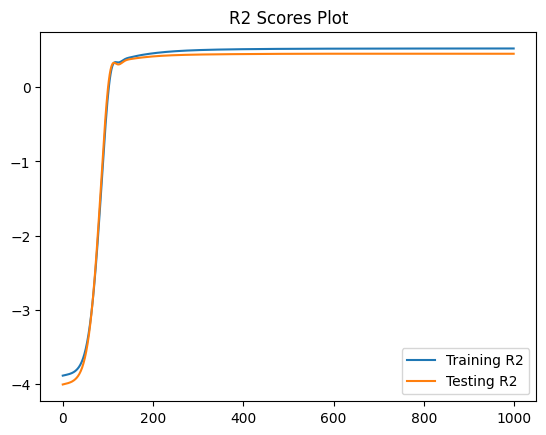

In [32]:
plt.plot(total_epochs, train_r2_scores, label="Training R2")
plt.plot(total_epochs, test_r2_scores, label="Testing R2")
plt.title("R2 Scores Plot")
plt.legend()
plt.show()